In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import joblib

In [ ]:
CLEAN_TMDB_FILE_PATH = "../datasets/clean/tmdb-movies/TMDB_movie_dataset_v11.csv"
CLEAN_MOVIELENS_RATINGS_PATH = "../datasets/clean/ml-32m/ratings.csv"

ML_API_TF_IDF_MATRIX_PATH = "../../ml-api/model/tf_idf_matrix.pkl"

In [3]:
tmdb = pd.read_csv(CLEAN_TMDB_FILE_PATH)
ratings = pd.read_csv(CLEAN_MOVIELENS_RATINGS_PATH)

In [4]:
tmdb.head()

,id,title,overview,genres,keywords,vote_average,vote_count,popularity,popularity_log,content
0,27205,Inception,"Cobb, a skilled thief who commits corporate es...","Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...",8.364,34495,83.952,4.442086,"Cobb, a skilled thief who commits corporate es..."
1,157336,Interstellar,The adventures of a group of explorers who mak...,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...",8.417,32571,140.241,4.950468,The adventures of a group of explorers who mak...
2,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...",8.512,30619,130.643,4.880094,Batman raises the stakes in his war on crime. ...
3,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...",7.573,29815,79.932,4.393609,"In the 22nd century, a paraplegic Marine is di..."
4,24428,The Avengers,When an unexpected enemy emerges and threatens...,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...",7.710,29166,98.082,4.595948,When an unexpected enemy emerges and threatens...


In [5]:
tmdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 37972 entries, 0 to 37971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              37972 non-null  int64  
 1   title           37972 non-null  str    
 2   overview        37725 non-null  str    
 3   genres          37883 non-null  str    
 4   keywords        31050 non-null  str    
 5   vote_average    37972 non-null  float64
 6   vote_count      37972 non-null  int64  
 7   popularity      37972 non-null  float64
 8   popularity_log  37972 non-null  float64
 9   content         37972 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 2.9 MB


In [6]:
ratings.head()

,userId,rating,movieId,tmdbId
0,1,4.0,17,4584
1,1,1.0,25,451
2,1,2.0,29,902
3,1,5.0,30,37557
4,1,5.0,32,63


In [7]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 31916931 entries, 0 to 31916930
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   rating   float64
 2   movieId  int64  
 3   tmdbId   int64  
dtypes: float64(1), int64(3)
memory usage: 974.0 MB


In [8]:
tmdb_id_to_index = pd.Series(tmdb.index, index=tmdb["id"]).to_dict()
ratings["rating"] = ratings["rating"] - ratings["rating"].mean()

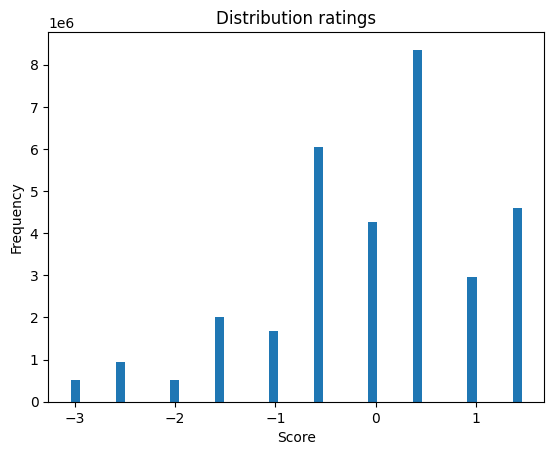

In [9]:
plt.hist(ratings["rating"], bins=50)
plt.title("Distribution ratings")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [10]:
print("min:", ratings["rating"].min())
print("max:", ratings["rating"].max())
print("mean:", ratings["rating"].mean())
print("std:", ratings["rating"].std())
print(np.percentile(ratings["rating"], [0, 25, 50, 75, 100]))

min: -3.0419925869439015
max: 1.4580074130560985
mean: -2.756102319345103e-16
std: 1.0581912389528363
[-3.04199259 -0.54199259 -0.04199259  0.45800741  1.45800741]


In [11]:
def find_in_dataset_by_substring(movie_name):
    results = tmdb[tmdb["title"].str.contains(movie_name, case=False, na=False)]
    return results.sort_values(by="popularity", ascending=False)

def find_in_dataset_by_id(movie_id):
    return tmdb[tmdb["id"] == movie_id]["title"]

In [12]:
#find_in_dataset_by_substring("spider-man")

In [13]:
find_in_dataset_by_id(27205)

0    Inception
Name: title, dtype: str

In [14]:
spiderman_fan_collaborative = {
  569094: 4.5 - 3.5,
  634649: 4 - 3.5,
  324857: 5 - 3.5,
  524434: 1 - 3.5,
  18224: 0.5 - 3.5
}

for id in spiderman_fan_collaborative.keys():
  print(f"{id}: {find_in_dataset_by_id(id)}")

569094: 952    Spider-Man: Across the Spider-Verse
Name: title, dtype: str
634649: 57    Spider-Man: No Way Home
Name: title, dtype: str
324857: 133    Spider-Man: Into the Spider-Verse
Name: title, dtype: str
524434: 451    Eternals
Name: title, dtype: str
18224: 21439    Bionicle 3: Web of Shadows
Name: title, dtype: str


Content based filtering

In [15]:
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(tmdb["content"])

In [16]:
def build_user_profile_content(ratings_dict):
    vectors = []
    weights = []

    for tmdb_id, rating in ratings_dict.items():
        if tmdb_id in tmdb_id_to_index:
            idx = tmdb_id_to_index[tmdb_id]
            vectors.append(tfidf_matrix[idx].toarray()[0])
            weights.append(rating + 3.5)

    vectors = np.array(vectors)
    weights = np.array(weights)

    # vážený průměr
    user_profile = np.average(vectors, axis=0, weights=weights)
    user_profile = user_profile.reshape(1, -1)

    return user_profile

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_content(user_vector, top_k=20):
    sims = cosine_similarity(user_vector, tfidf_matrix).flatten()
    top_idx = sims.argsort()[-top_k:][::-1]
    return tmdb.iloc[top_idx][["title", "vote_average"]]

In [ ]:
spiderman_fan = build_user_profile_content(spiderman_fan_collaborative)

recommend_content(spiderman_fan)

,title,vote_average
952,Spider-Man: Across the Spider-Verse,8.442
133,Spider-Man: Into the Spider-Verse,8.404
57,Spider-Man: No Way Home,7.990
68,Spider-Man,7.279
33277,In the Spider's Web,4.789
32,Spider-Man: Homecoming,7.345
3327,Arachnophobia,6.373
403,Doctor Strange in the Multiverse of Madness,7.355
17014,Daredevil vs. Spider-Man,7.400
11195,Mighty Morphin Power Rangers: Once & Always,6.600


Collaborative filtering

In [19]:
ratings[ratings["tmdbId"].isna()]

,userId,rating,movieId,tmdbId


In [20]:
ratings[ratings["userId"].isna()]

,userId,rating,movieId,tmdbId


In [21]:
movie_stats = ratings.groupby("tmdbId").agg(
    avg=("rating", "mean"),
    count=("rating", "count")
)

good_movies = movie_stats[
    (movie_stats["count"] >= 0)
].index

ratings_filtered = ratings[ratings["tmdbId"].isin(good_movies)]

In [22]:
len(np.sort(ratings["tmdbId"].unique()))

43817

In [23]:
ratings_test = ratings_filtered


user_ids = np.sort(ratings_test["userId"].unique())
movie_ids = np.sort(ratings_test["tmdbId"].unique())

user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}

n_users = len(user_ids)
n_items = len(movie_ids)

rows = ratings_test["userId"].map(user_map)
cols = ratings_test["tmdbId"].map(movie_map)
data = ratings_test["rating"]

R = csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

svd = TruncatedSVD(n_components=35)
U = svd.fit_transform(R)
V = svd.components_

In [24]:
U

array([[ 0.3101429 , -0.44448128, -0.26028971, ...,  1.70044581,
         0.14327707, -0.20994971],
       [ 0.10252899,  0.98464728, -0.13172725, ...,  1.10362277,
        -0.65603549, -1.1470731 ],
       [ 1.39098002, -0.26788952,  0.55826956, ...,  1.22708471,
         0.18447865,  1.0495178 ],
       ...,
       [ 0.81901788,  0.68387642, -0.31882857, ...,  0.39850158,
        -0.70192158, -0.20112733],
       [ 1.59855487,  0.78694777,  0.75796105, ..., -0.94248237,
         0.99199537,  0.26040335],
       [ 3.59022596,  1.82686107,  2.39621479, ...,  1.52897155,
         0.25226112,  0.27539745]], shape=(200948, 35))

In [25]:
V

array([[ 3.51711282e-04,  1.38121990e-04, -2.92794935e-03, ...,
         1.33889118e-05,  1.11638455e-05,  4.30413365e-06],
       [ 2.18268617e-04, -8.71286337e-05,  9.31238843e-03, ...,
        -6.94809042e-07,  2.99544831e-06,  2.85315177e-05],
       [-1.11626047e-03, -3.44939053e-04, -4.98812244e-03, ...,
         3.99662195e-05,  6.83665483e-06, -6.79797740e-05],
       ...,
       [-4.42644402e-04, -3.85314587e-05,  1.50574582e-02, ...,
         3.84805910e-05, -1.69989350e-06,  5.43624400e-05],
       [-4.53979700e-04, -5.08478806e-04,  5.31381075e-03, ...,
         1.22239371e-05, -3.38295454e-05,  1.27616378e-04],
       [-8.43027677e-04, -1.66465846e-04,  4.37808214e-03, ...,
        -1.25332621e-04, -6.22604221e-05, -1.81819450e-05]],
      shape=(35, 43817))

In [26]:
_indices = []
_ratings = []

for tmdb_id, rating in spiderman_fan_collaborative.items():
    if tmdb_id in movie_map:
        _indices.append(movie_map[tmdb_id])
        _ratings.append(rating)
    
V_sub = V[:, _indices]
r = np.array(_ratings)
user_vector = np.linalg.lstsq(V_sub.T, r, rcond=None)[0]
scores = user_vector @ V
scores

array([ 0.05690681,  0.04518471, -0.96556675, ..., -0.00854446,
        0.01680798, -0.00201994], shape=(43817,))

In [27]:
print("min:", scores.min())
print("max:", scores.max())
print("mean:", scores.mean())
print("std:", scores.std())
print(np.percentile(scores, [0, 25, 50, 75, 100]))

min: -36.09785983234248
max: 23.31286534545472
mean: -0.1363622076485757
std: 1.2250442922993725
[-3.60978598e+01 -1.02903702e-01 -2.23943994e-02  1.28448115e-02
  2.33128653e+01]


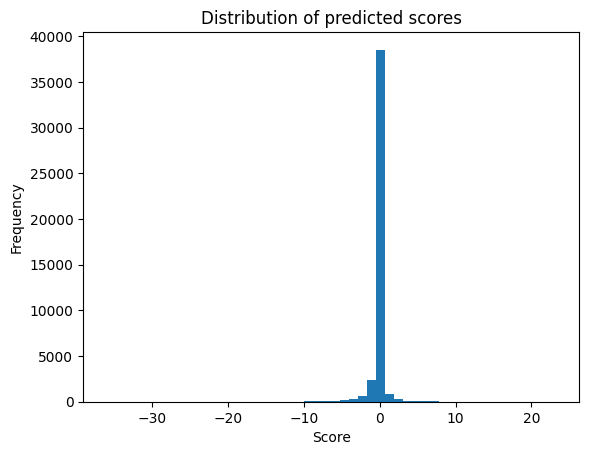

In [28]:
plt.hist(scores, bins=50)
plt.title("Distribution of predicted scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

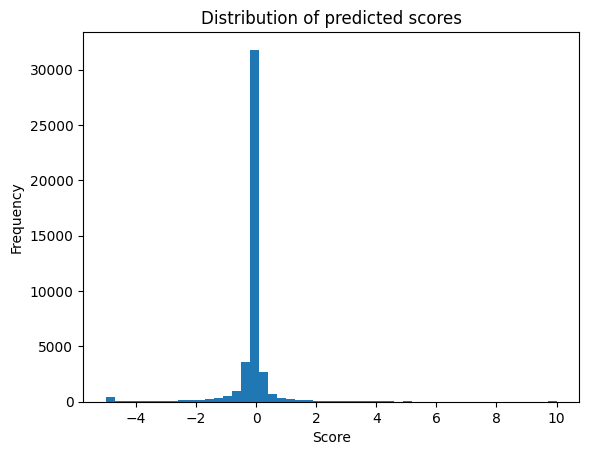

In [29]:
scores_cut = np.clip(scores, -5, 10)
plt.hist(scores_cut, bins=50)
plt.title("Distribution of predicted scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [30]:
top_k = 100

top_idx = scores.argsort()[::-1][:top_k]
top_movies = [(movie_ids[i], scores[i]) for i in top_idx]

results = []

tmdb_indexed = tmdb.set_index("id")

for movie_id, score in top_movies:
    if movie_id in tmdb_indexed.index:
        title = tmdb_indexed.loc[movie_id]["title"]
        results.append((title, score))

results

[('Titanic', np.float64(23.31286534545472)),
 ('The Matrix', np.float64(20.565920977725874)),
 ('Toy Story', np.float64(19.067717429661045)),
 ('The Lion King', np.float64(18.9693881193145)),
 ('Borat: Cultural Learnings of America for Make Benefit Glorious Nation of Kazakhstan',
  np.float64(16.826037886155742)),
 ('The 40 Year Old Virgin', np.float64(16.58784978499211)),
 ('Meet the Parents', np.float64(16.355839381181628)),
 ('The Hangover', np.float64(16.19447327423505)),
 ('Superbad', np.float64(15.811113859242727)),
 ('Beauty and the Beast', np.float64(15.283913564194703)),
 ('Cast Away', np.float64(14.025252373412757)),
 ('American Pie', np.float64(13.680099818723107)),
 ('The Social Network', np.float64(13.488215882941406)),
 ('The Wolf of Wall Street', np.float64(13.37860406923243)),
 ('Harry Potter and the Prisoner of Azkaban', np.float64(13.061858980630928)),
 ('Aladdin', np.float64(12.426472252022275)),
 ('Catch Me If You Can', np.float64(12.095356933783274)),
 ("Harry Pott

Saving this abhorrent "progress"

In [ ]:
joblib.dump(tfidf_matrix, ML_API_TF_IDF_MATRIX_PATH)